In [1]:
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
from torch import tensor as tt

import sys as sys
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import math 
import re
from scipy.spatial import distance_matrix
from sklearn.metrics.pairwise import euclidean_distances 
import pandas as pd
import netCDF4 as nc


In [2]:
def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

def torch_Matern_05(dist_matrix, rho):
    K = torch.exp(-dist_matrix / rho)
    return K

def sample_Gauss_fixed_noise(fixed_noise, chol_cov):
    return fixed_noise @ chol_cov.T

def revert_to_indep_gauss(dependent_samples, chol_cov):
    return dependent_samples @ torch.linalg.inv(chol_cov).T

norm = torch.distributions.Normal(0.0, 1.0)


In [3]:
#################################################################### Loading GNM ####################################################################
sys.path.append('../')

import pickle


GNM_output = pickle.load( open("trainset_output_1999-07_2019-07.pkl","rb") )
#################################################################### Problematic locations? ###############################################################

location_keys = list(GNM_output.keys())                 # '([0, 16], [44, 60])', ...
output_keys = list(GNM_output[location_keys[0]].keys()) # 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'date', 5'pred_p', 6'mask', 7'idx_loc_in_region'

# May have to remove a location that doesn't have the correct number of days:
location_keys.remove(location_keys[344]) #to remove for gamma_20_20 from 1999-2019 
#location_keys.remove(location_keys[336]) #to remove for gamma_20_20 from 1979-1999
#################################################################### Utility functions ####################################################################
def give_lat_lon(location_key):
    return [ int(re.findall(r'\d+',string)[0]) for string in location_key.split(',')]

def is_loc_land(location,row,column):
    return GNM_output[location]['mask'][0][row][column]

#location_keys.remove('lat_50.95_49.35_lon_-4.55_-2.95') # 'lat_50.95_49.35_lon_-4.55_-2.95' has no data after week indexed 255, so I did not consider it.
day_dates = [pd.to_datetime(i).date() for i in GNM_output[location_keys[0]]['date']]
output_keys.remove('idx_loc_in_region') # not usefull
output_keys.remove('date') # no more usefull

#################################################################### Making list for land locations ####################################################################
#GNM_landonly[location][param][day]
# 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'pred_p', 5'location'

GNM_landonly = [] 
land_counter = -1
for location in tqdm(location_keys):
    for col in range(4):
        for row in range(4):
            if not is_loc_land(location,row,col):#check if land
               continue  
            land_counter+=1
            GNM_landonly.append([[],[],[],[],[]]) # parameters except location
            temp_lat_lon = give_lat_lon(location)
            GNM_landonly[land_counter].append([temp_lat_lon[1]-8+row,(temp_lat_lon[2])+6+col]) #location
            for param_idx,param in enumerate(output_keys[:-1]):
                for day in range(len(GNM_output[location_keys[0]]['pred_mu'])):
                    qqq = [location,param,day,row,col]
                    GNM_landonly[land_counter][param_idx].append(GNM_output[location][param][day][row,col])

dist_mat = distance_matrix(np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]))

#################################################################### Elevation data ####################################################################
fn = 'topo_0.1_degree.nc'
ds = nc.Dataset(fn)
h = ds['Band1'][:]
h = np.flip(np.matrix(h),axis=0)

# load obs_norm_all and censor_levels_di
obs_norm_all = np.load('obs_norm_all_trainCdf_1999_2019.npy')
obs_norm_all = tt(obs_norm_all)
censor_levels_di = np.load('censor_levels_di_trainCdf_1999_2019.npy')
censor_levels_di = tt(censor_levels_di)
censor_levels_u = scs.norm.cdf(censor_levels_di)

100%|██████████| 344/344 [01:12<00:00,  4.77it/s]


In [120]:
def sample_uncensored_copula(alpha,theta,n_sims,GNM_landonly,fixed_noise=None, return_dist_matrix=False, return_cov_matrix=False):
    ''' 
    Sample from a Gaussian copula model.

    Parameters:
        alpha: float, elevation parameter
        theta: float, Matern parameter
        n_sims: int, number of simulations per day
        GNM_landonly: list, list of location data from marginal model
        fixed_noise: tensor, fixed noise for sampling
        return_dist_matrix: bool, return distance matrix
        return_cov_matrix: bool, return covariance matrix
    '''
    if fixed_noise==None: # have to generate my own noise
        fixed_noise = torch.randn(n_sims,len(GNM_landonly), dtype=torch.float64)
    # distance matrix
    estimated_dist_3d = torch.column_stack([
    tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]), # this part is for lat lon
    alpha*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)]) # this part is for elevation
    estimated_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
    # covariance matrix
    estimated_cov_matrix = torch_Matern_05(estimated_dist_matrix, theta)
    # sampling with Cholesky decomposition
    sim_z_est = sample_Gauss_fixed_noise(fixed_noise, torch.linalg.cholesky(estimated_cov_matrix))

    out = [sim_z_est]
    if return_dist_matrix:
        out.append(estimated_dist_matrix)
    if return_cov_matrix:
        out.append(estimated_cov_matrix)
    return tuple(out)

# Example
#sims = sample_censored_copula(alpha=0,theta=34.8212,n_sims_per_day=10,censor_levels=censor_levels_di[:2],fixed_noise=None, return_dist_matrix=True, return_cov_matrix=True)


def plot_samples(samples, GNM_landonly, vmin=None, vmax=None):
    """
    Plot a series of scatter plots for the given samples.

    Parameters:
        samples (torch.Tensor): Input samples of shape (n, 4087).
        GNM_landonly (list): List of location data.
        vmin (float): Minimum value for color scale.
        vmax (float): Maximum value for color scale.
    """
    n = samples.shape[0]

    # Check if samples is a torch tensor and requires gradients
    if isinstance(samples, torch.Tensor):
        samples = samples.detach().numpy()

    
    for i in range(n):
        fig, ax = plt.subplots(figsize=(14,8))
        
        if vmin is None or vmax is None:
            vmin_ = samples[i].min().item()
            vmax_ = samples[i].max().item()
        
        sc = ax.scatter(
            [GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
            [-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], 
            c=samples[i], cmap='inferno_r', vmin=vmin_, vmax=vmax_, s=20,marker='s'
        )
        
        ax.set_title(f'Sample {i} Scatter Plot')
        fig.colorbar(sc, ax=ax)
        plt.show()

# Example
# plot_samples(sims[0][0,0,:].unsqueeze(0), GNM_landonly)

def GNM_z_to_y(x_one_day_all_locs,day_idx):
    '''  
    Convert latent Gaussian copula samples on the z space to observed samples on the y space.
    
    Parameters:
        x_one_day_all_locs: tensor, GNM z values
        day_idx: int, day index
    '''
    m = np.array([GNM_landonly[l][0][day_idx] for l in range(len(x_one_day_all_locs))])
    d = np.array([GNM_landonly[l][1][day_idx] for l in range(len(x_one_day_all_locs))])
    p = np.array([GNM_landonly[l][4][day_idx] for l in range(len(x_one_day_all_locs))])
    sim_u = scs.norm.cdf(x_one_day_all_locs)
    censored_u = (sim_u+p-1)/p
    return np.nan_to_num(scs.gamma(a=1/d,scale=m*d).ppf(censored_u),nan=0)



In [98]:
fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all)[:100], torch.linalg.cholesky(torch.cov(obs_norm_all.T)))

C:\Users\u1819911\AppData\Local\Temp\ipykernel_5268\540969399.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_noise_reverted = revert_to_indep_gauss(tt(obs_norm_all)[:100], torch.linalg.cholesky(torch.cov(obs_norm_all.T)))


# a=0 and theta=34.8212

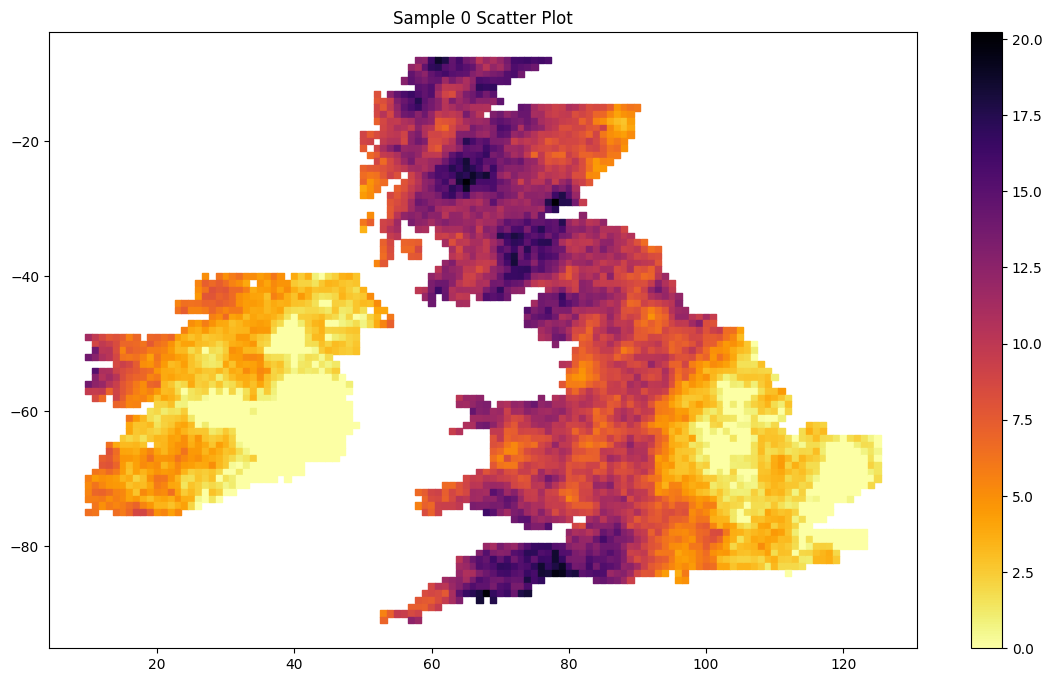

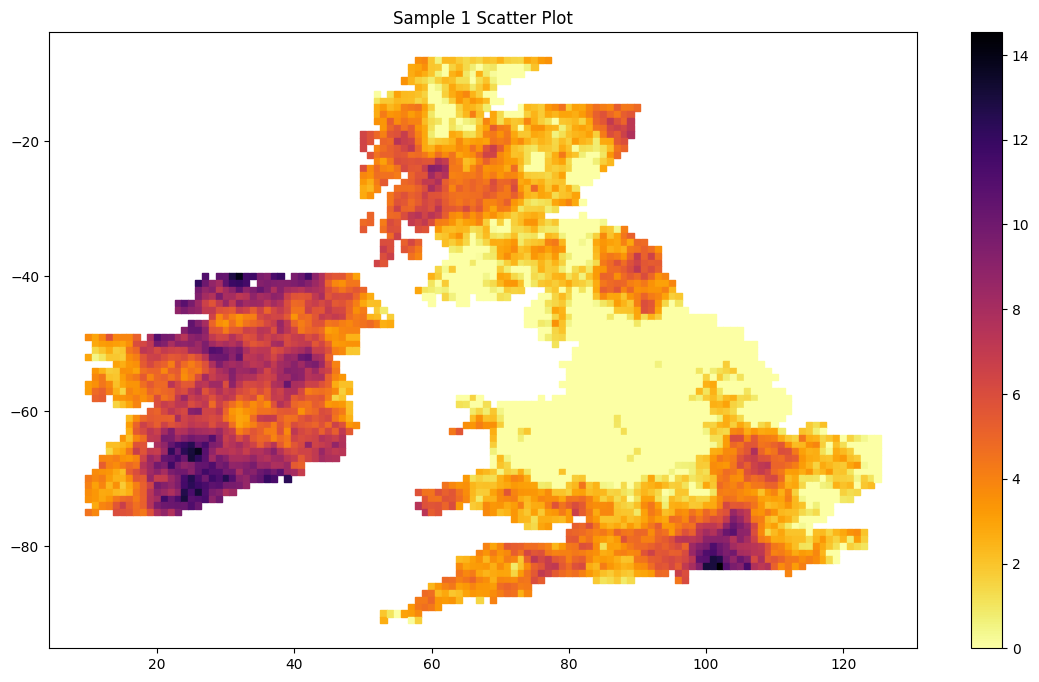

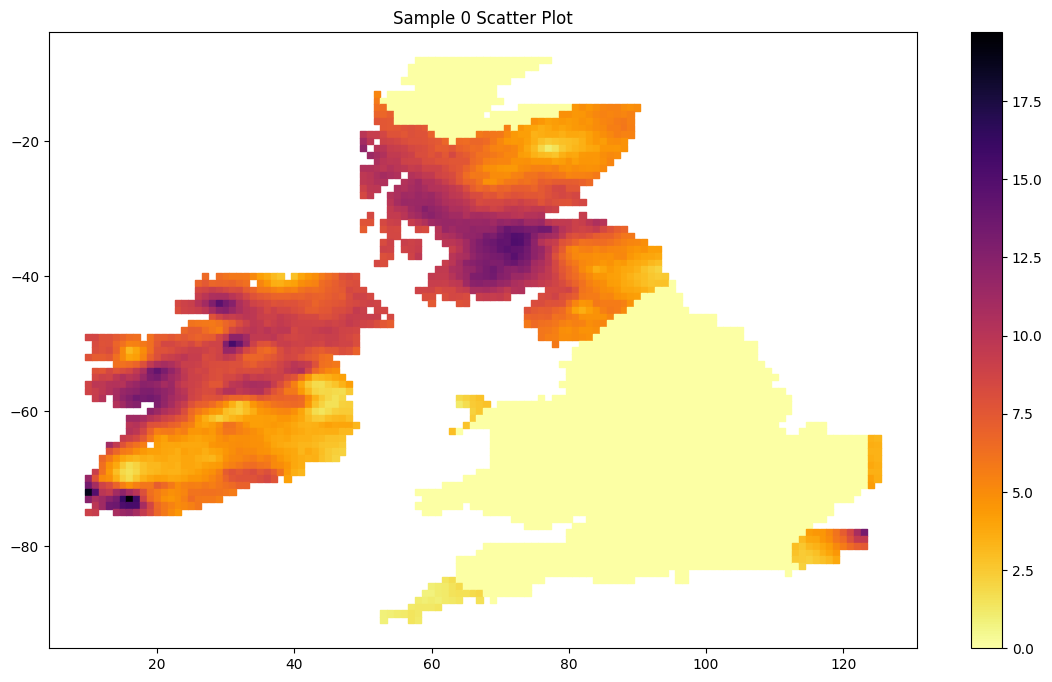

In [176]:
sims_a0,dist_mat_a0,cov_mat_a0 = sample_uncensored_copula(alpha=0,theta=34.8212,n_sims=100,GNM_landonly=GNM_landonly,fixed_noise=None, return_dist_matrix=True, return_cov_matrix=True)
day_shown = 17
plot_samples(tt([GNM_z_to_y(sims_a0[sim,:].unsqueeze(0),day_shown) for sim in range(2)]),GNM_landonly)
plot_samples(tt([GNM_landonly[l][3][day_shown] for l in range(len(GNM_landonly))]).unsqueeze(0),GNM_landonly)


## Energy score

In [151]:
from scipy.spatial.distance import pdist

def Spatial_Energy_Score_single_day(beta,observations_y,simulations_Y):

    n = len(observations_y)
    m = len(simulations_Y)
    observations_y = np.array(observations_y)
    simulations_Y = np.array(simulations_Y)

    # First part |Y-y|. Gives the L2 dist scaled by power beta. Is a vector of length n/one value per location.
    diff_Y_y = np.power(
            np.linalg.norm(
                np.tile(observations_y,(m,1)) -
                simulations_Y,
            axis=1),
        beta)

    #Second part |Y-Y'|. 2* because pdist counts only once.
    diff_Y_Y = 2 * np.power(
        pdist(simulations_Y)
    ,beta)

    Energy = 2 * np.mean(diff_Y_y) - np.sum(diff_Y_Y)/(m*(m-1))
    return Energy

In [179]:
tt([GNM_landonly[l][3][day_shown] for l in range(len(GNM_landonly))]).unsqueeze(0).shape

torch.Size([1, 4087])

In [184]:
tt([GNM_z_to_y(sims_a0[sim,:].unsqueeze(0),day_shown) for sim in range(2)]).squeeze(1).shape

torch.Size([2, 4087])

In [191]:
Spatial_Energy_Score_single_day(0.5,
                                tt([GNM_landonly[l][3][day_shown] for l in range(len(GNM_landonly))]).unsqueeze(0),
                                tt([GNM_z_to_y(sims_a0[sim,:].unsqueeze(0),day_shown) for sim in range(20)]).squeeze(1)
                                )

C:\Users\u1819911\AppData\Local\Temp\ipykernel_5268\3119349001.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  observations_y = np.array(observations_y)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5268\3119349001.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  simulations_Y = np.array(simulations_Y)


np.float64(19.75519161816521)

In [245]:
(tt([GNM_landonly[l][3][d+3:d+5] for l in range(len(GNM_landonly))])).T.shape

torch.Size([2, 4087])

  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\u1819911\AppData\Local\Temp\ipykernel_5268\3119349001.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  observations_y = np.array(observations_y)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5268\3119349001.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  simulations_Y = np.array(simulations_Y)
  5%|▌         | 5/100 [00:00<00:02, 42.13it/s]

0 no
1 no
2 no
3 no
4 no
5 no
6 no
7 no
8 no


 21%|██        | 21/100 [00:00<00:01, 48.20it/s]

12 no
13 no
14 no
15 no
16 no
17 no
18 no
19 no
20 no


 31%|███       | 31/100 [00:00<00:01, 48.72it/s]

...

71 no
72 no
73 no
74 no
75 no
76 no
77 no
78 no


 86%|████████▌ | 86/100 [00:02<00:00, 38.62it/s]

79 no
80 no
81 no
82 no
83 no
84 no
85 no
86 no
87 no
88 no


100%|██████████| 100/100 [00:03<00:00, 31.38it/s]

89 no
90 no
91 no
92 no
93 no
94 no
95 no
96 no
97 no
98 no
99 no
2.5531015462421487


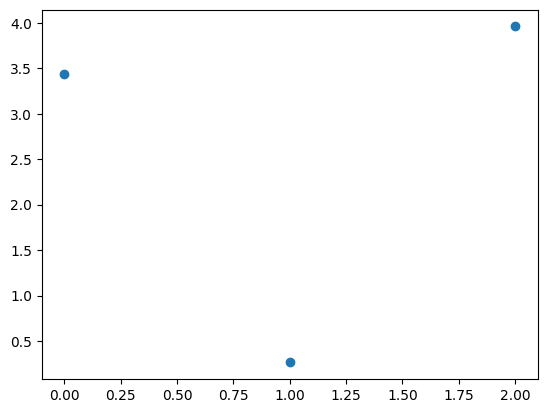

In [ ]:
Energy_diagnostic = []
for d in tqdm(range(len(GNM_landonly[0][3]))):
    Energy_diagnostic.append(Spatial_Energy_Score_single_day(0.2,
                                tt([GNM_landonly[l][3][d] for l in range(len(GNM_landonly))]).unsqueeze(0),
                                tt([GNM_z_to_y(sims_a0[sim,:].unsqueeze(0),d) for sim in range(100)]).squeeze(1)
                                ))

plt.scatter(range(len(Energy_diagnostic)),Energy_diagnostic)
print(np.mean(Energy_diagnostic))

3.0723929524352416


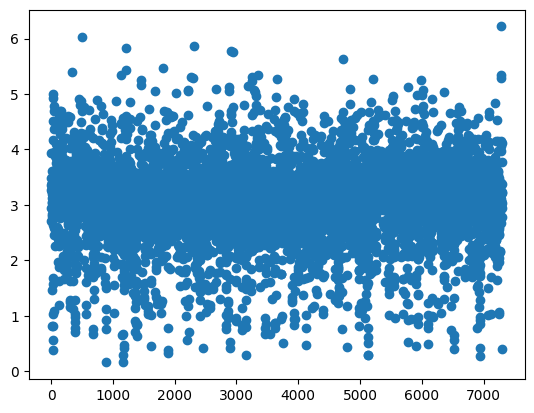

In [203]:
plt.scatter(range(len(Energy_diagnostic)),Energy_diagnostic)
print(np.mean(Energy_diagnostic))

## Variogram

In [234]:
def Variogram_single_day(observations_y,simulations_Y,distance_matrix):

    n = len(observations_y)
    m = len(simulations_Y)
    y = np.array(observations_y)
    Y = np.array(simulations_Y)

    # inverse distance matrix, for weights w_ij:
    w_ij = np.nan_to_num( 1/distance_matrix, copy=False, nan=0, posinf=0, neginf=0)

    # |y_i - y_j| first part of Variogram
    diff_y_y = euclidean_distances(y.reshape(-1,1))

    # |Y_k,i - Y_k,j| second part of Variogram
    diff_Y_Y = np.mean(np.abs(np.tile(Y,n).reshape(m,n*n)-np.repeat(Y,n).reshape(m,n*n)),axis=0).reshape(n,n)

    Variogram = np.multiply(
        w_ij,
        np.power(
            diff_y_y - diff_Y_Y
        ,2)
    )

    return np.sum(Variogram)

dist_mat = distance_matrix(np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]))


In [ ]:
tt([GNM_landonly[l][3][d] for l in range(len(GNM_landonly))]).unsqueeze(0),
                                tt([GNM_z_to_y(sims_a0[sim,:].unsqueeze(0),d) for sim in range(1)]).squeeze(1)

In [216]:
tt([GNM_landonly[l][3][d] for l in range(len(GNM_landonly))]).shape

torch.Size([4087])

60.0

0it [00:00, ?it/s]C:\Users\u1819911\AppData\Local\Temp\ipykernel_5268\2246193038.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = np.array(observations_y)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5268\2246193038.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Y = np.array(simulations_Y)
C:\Users\u1819911\AppData\Local\Temp\ipykernel_5268\2246193038.py:9: RuntimeWarning: divide by zero encountered in divide
  w_ij = np.nan_to_num( 1/distance_matrix, copy=Fal

17652583.132355068


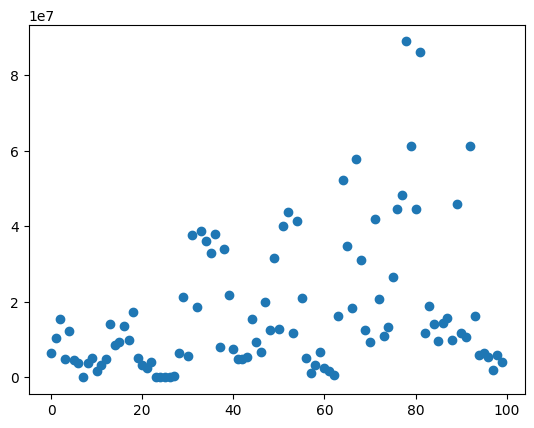

In [238]:
Variogram_diagnostic = []
for i,d in tqdm(enumerate(range(100))):
    Variogram_diagnostic.append(Variogram_single_day(tt([GNM_landonly[l][3][d] for l in range(len(GNM_landonly))]),
                     tt([GNM_landonly[l][3][d+3] for l in range(len(GNM_landonly))]).unsqueeze(0),
                     dist_mat
                     ) )
    
plt.scatter(range(len(Variogram_diagnostic)),Variogram_diagnostic)
print(np.mean(Variogram_diagnostic))